In [1]:
import copy
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
# Загрузка изображения
image = cv2.imread("sar_1.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Text(0.5, 1.0, 'Gaussian noise')

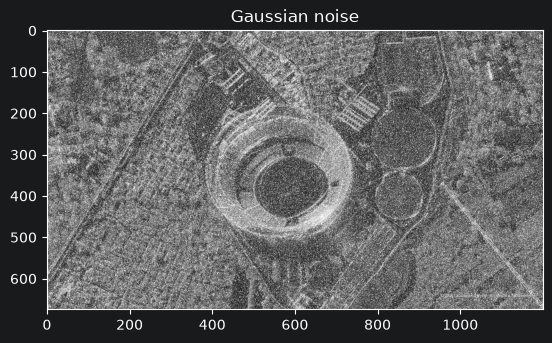

In [3]:
# Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")
plt.title("Gaussian noise")

Text(0.5, 1.0, 'Salt and pepper noise')

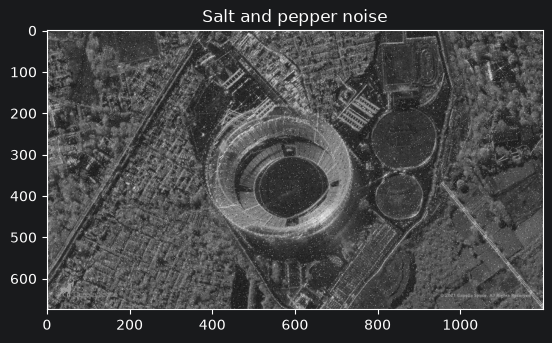

In [4]:
# Соль и перец
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")
plt.title("Salt and pepper noise")

Text(0.5, 1.0, 'Constant noise')

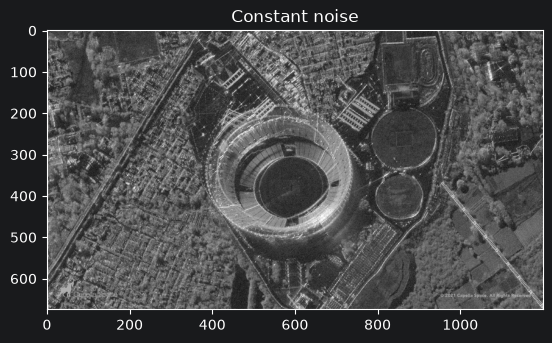

In [5]:
# Постоянный шум
const_noise = np.full(image_gray.shape, 25, np.uint8)
image_const_noise = cv2.add(image_gray, const_noise)

plt.imshow(image_const_noise, cmap="gray")
plt.title("Constant noise")

In [6]:
# Вычисление метрик зашумлённых изображений
noise_names = ["Gauss", "Salt and pepper", "Constant"]
noise_images = [image_noise_gauss, image_sp, image_const_noise]

for i in range(len(noise_names)):
    mse_noise = mean_squared_error(image_gray, noise_images[i])
    ssim_noise = structural_similarity(image_gray, noise_images[i])
    print("noise =", noise_names[i], "MSE:", mse_noise, "SSIM:", ssim_noise)

noise = Gauss MSE: 4230.673058024691 SSIM: 0.18699266800035377
noise = Salt and pepper MSE: 389.6003148148148 SSIM: 0.7211260570981464
noise = Constant MSE: 624.9169679012346 SSIM: 0.954407875487614


In [7]:
# Фильтры и их параметры
def median_filter(img, k):
    return cv2.medianBlur(img, k)

def gauss_filter(img, k):
    return cv2.GaussianBlur(img, (k, k), 0)

def bilateral_filter(img, sigma):
    return cv2.bilateralFilter(img, 9, sigma, sigma)

def nlm_filter(img, h):
    return cv2.fastNlMeansDenoising(img, h=h)

filter_names = ["Median", "Gauss", "Bilateral", "NLM"]
filter_funcs = [median_filter, gauss_filter, bilateral_filter, nlm_filter]
filter_params = [[3, 5, 7],
                 [3, 5, 7],
                 [25, 75, 150],
                 [30, 50, 70]]
param_names = ["ksize", "ksize", "sigma", "h"]

In [8]:
# Прогон фильтров по обоим типам шума с различными параметрами
results = []

for n in range(len(noise_names)):
    for f in range(len(filter_names)):
        for param in filter_params[f]:
            filtered = filter_funcs[f](noise_images[n], param)
            mse_f = mean_squared_error(image_gray, filtered)
            ssim_f = structural_similarity(image_gray, filtered)
            results.append((noise_names[n], filter_names[f], param_names[f] + " = " + str(param), mse_f, ssim_f, filtered))
            print("noise =", noise_names[n], "filter =", filter_names[f], param_names[f], "=", param,
                  "MSE:", round(mse_f, 2), "SSIM:", round(ssim_f, 4))

noise = Gauss filter = Median ksize = 3 MSE: 1038.05 SSIM: 0.4282
noise = Gauss filter = Median ksize = 5 MSE: 706.03 SSIM: 0.4702
noise = Gauss filter = Median ksize = 7 MSE: 682.57 SSIM: 0.4336
noise = Gauss filter = Gauss ksize = 3 MSE: 1903.45 SSIM: 0.4403
noise = Gauss filter = Gauss ksize = 5 MSE: 1764.64 SSIM: 0.486
noise = Gauss filter = Gauss ksize = 7 MSE: 1721.2 SSIM: 0.4925
noise = Gauss filter = Bilateral sigma = 25 MSE: 3783.21 SSIM: 0.1815
noise = Gauss filter = Bilateral sigma = 75 MSE: 1837.55 SSIM: 0.3145
noise = Gauss filter = Bilateral sigma = 150 MSE: 1547.91 SSIM: 0.4413
noise = Gauss filter = NLM h = 30 MSE: 2937.21 SSIM: 0.2536
noise = Gauss filter = NLM h = 50 MSE: 1761.6 SSIM: 0.3611
noise = Gauss filter = NLM h = 70 MSE: 1836.02 SSIM: 0.3057
noise = Salt and pepper filter = Median ksize = 3 MSE: 95.79 SSIM: 0.8161
noise = Salt and pepper filter = Median ksize = 5 MSE: 194.15 SSIM: 0.633
noise = Salt and pepper filter = Median ksize = 7 MSE: 260.05 SSIM: 0.522

In [9]:
# Лучший фильтр для каждого типа шума (по SSIM и по MSE)
for n in range(len(noise_names)):
    noise_results = [r for r in results if r[0] == noise_names[n]]
    best_ssim = max(noise_results, key=lambda r: r[4])
    best_mse = min(noise_results, key=lambda r: r[3])
    print("noise =", noise_names[n])
    print("best by SSIM:", best_ssim[1], best_ssim[2], "SSIM:", round(best_ssim[4], 4), "MSE:", round(best_ssim[3], 2))
    print("best by MSE: ", best_mse[1], best_mse[2], "SSIM:", round(best_mse[4], 4), "MSE:", round(best_mse[3], 2), "\n")

noise = Gauss
best by SSIM: Gauss ksize = 7 SSIM: 0.4925 MSE: 1721.2
best by MSE:  Median ksize = 7 SSIM: 0.4336 MSE: 682.57 

noise = Salt and pepper
best by SSIM: Median ksize = 3 SSIM: 0.8161 MSE: 95.79
best by MSE:  Median ksize = 3 SSIM: 0.8161 MSE: 95.79 

noise = Constant
best by SSIM: Gauss ksize = 3 SSIM: 0.8423 MSE: 689.99
best by MSE:  Bilateral sigma = 25 SSIM: 0.7574 MSE: 680.6 



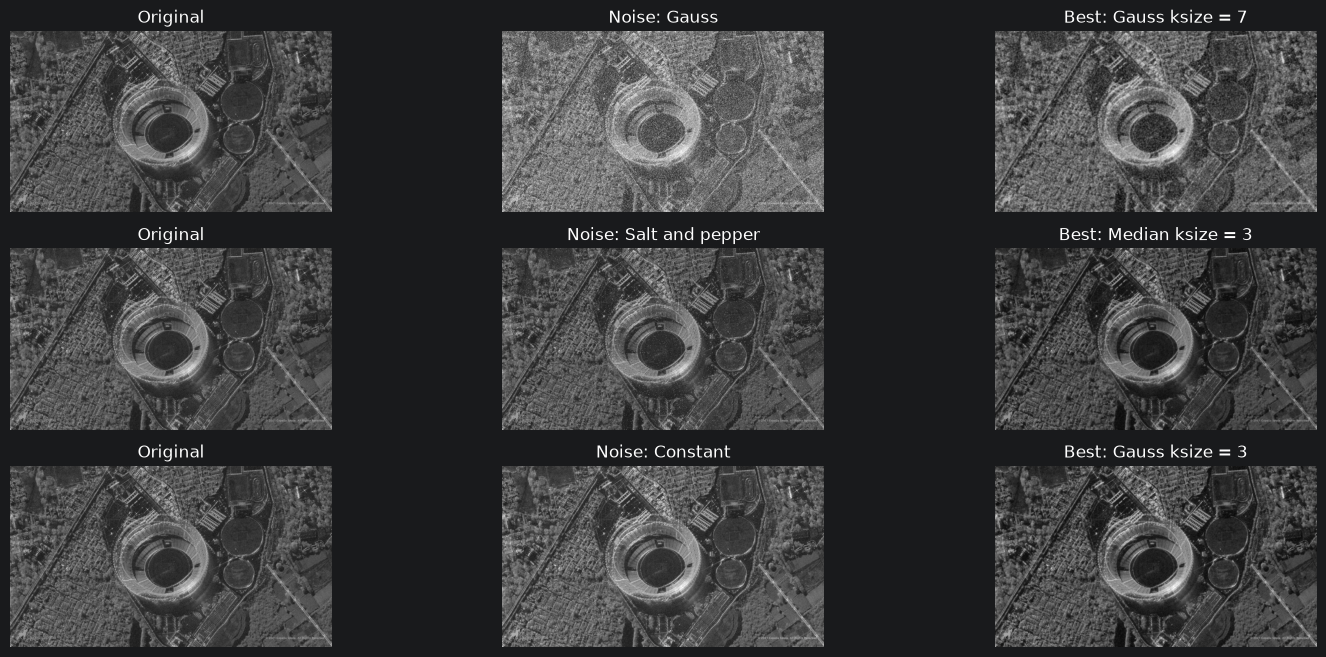

In [10]:
# Визуальное сравнение оригинала, зашумлённия и лучшего результата
_, axes = plt.subplots(len(noise_names), 3, figsize=(18, 8))

for n in range(len(noise_names)):
    noise_results = [r for r in results if r[0] == noise_names[n]]
    best = max(noise_results, key=lambda r: r[4])
    axes[n, 0].imshow(image_gray, cmap="gray")
    axes[n, 0].set_title("Original")
    axes[n, 1].imshow(noise_images[n], cmap="gray")
    axes[n, 1].set_title("Noise: " + noise_names[n])
    axes[n, 2].imshow(best[5], cmap="gray")
    axes[n, 2].set_title("Best: " + best[1] + " " + best[2])
    for col in range(3):
        axes[n, col].axis("off")

In [11]:
# Итог
# Шум Гаусса
#   по MSE лучше оказался медианный фильтр (MSE = 683,  SSIM = 0.43), а по SSIM фильтр Гаусса (MSE = 1721, SSIM = 0.49)
# Шум соль-перец
#   по MSE и SSIM лучшим оказался медианный фильтр (MSE = 96, SSIM = 0.82)